In [1]:
"""
Created on Sun Jul 27 14:37:46 2025

@author: huzefa
"""

'\nCreated on Sun Jul 27 14:37:46 2025\n\n@author: huzefa\n'

In [2]:
import numpy as np
from scipy.io import loadmat
from matplotlib.pyplot import *
import pandas as pd

In [3]:
#Importing data
mat_data = loadmat('../Datasets/data.mat') # load mat-file

In [4]:
#Creating proper structured dataframes
wavelengths = mat_data['WAV'][0] # dictionary element with the key = 'WAV' is a list of list.
species=['Cr','Ni','Co'] # Name of the species in the order specified in the data
species_con=pd.DataFrame(np.concatenate([mat_data['PureCrCONC'],mat_data['PureNiCONC'],
mat_data['PureCoCONC']],axis=1),columns=species)
species_abs=pd.DataFrame(np.concatenate([mat_data['PureCr'],mat_data['PureNi'],
mat_data['PureCo']],axis=0),
columns=wavelengths,index=species)

In [5]:
#Concentration of each species in the mixtures (each repeated 5 times) - corresponds to Y/output
mixture_con = pd.DataFrame(mat_data['CONC'],columns=species)
mixture_abs = pd.DataFrame(mat_data['DATA'],columns=wavelengths) # absorbance data for each wavelength corresponds to X/input

In [6]:
#Concentration of species for absorbance measurement
print(species_con)
#Absorbance spectra of each species at the given concentration
print(species_abs)

       Cr      Ni     Co
0  0.0764  0.1965  0.172
         300       302       304       306       308       310       312  \
Cr  0.290314  0.277074  0.248891  0.255931  0.282883  0.297658  0.239670   
Ni  0.169520  0.161845  0.140849  0.163610  0.200663  0.182780  0.207169   
Co  0.373698  0.415131  0.308090  0.342158  0.344152  0.291692  0.268926   

         314       316       318  ...       632       634       636       638  \
Cr  0.307846  0.387466  0.500966  ...  0.473480  0.452260  0.428558  0.405090   
Ni  0.294027  0.400558  0.557912  ...  0.278854  0.289174  0.303482  0.309128   
Co  0.333201  0.411865  0.581156  ...  0.053933  0.052933  0.051943  0.051567   

         640       642       644       646       648       650  
Cr  0.379664  0.354406  0.332057  0.310160  0.288366  0.271657  
Ni  0.313848  0.321905  0.330968  0.338282  0.350301  0.357793  
Co  0.050267  0.050233  0.049633  0.048738  0.047467  0.046933  

[3 rows x 176 columns]


In [7]:
'''
Function to plot spectra
Arguments: df (pandas.DataFrame), labels (list), header (string), vlines (boolean)
Returns: NoneType
'''
def plot_spectra(df,labels,header,vlines):
    fig, ax = subplots(figsize=(15,4))
    df.plot(ax=ax)
    ax.legend(labels,loc='best');
    ax.grid(True)
    ax.set(title=header,xlabel='Wavelength (nm)',ylabel='Absorbance')
    ax.set_ylim(-0.3,1.3)
    if vlines:
        vlines={408:'b',394:'orange',512:'g',574:'b'}
        for i in vlines:
            ax.axvline(x=i,color=vlines[i]) # drawing a blue vertical line at 408nm
            ax.text(i+1,0.6,str(i),rotation=90)
            # writing the wavelength value corresonding to the vertical line and placing the text vertically rotated

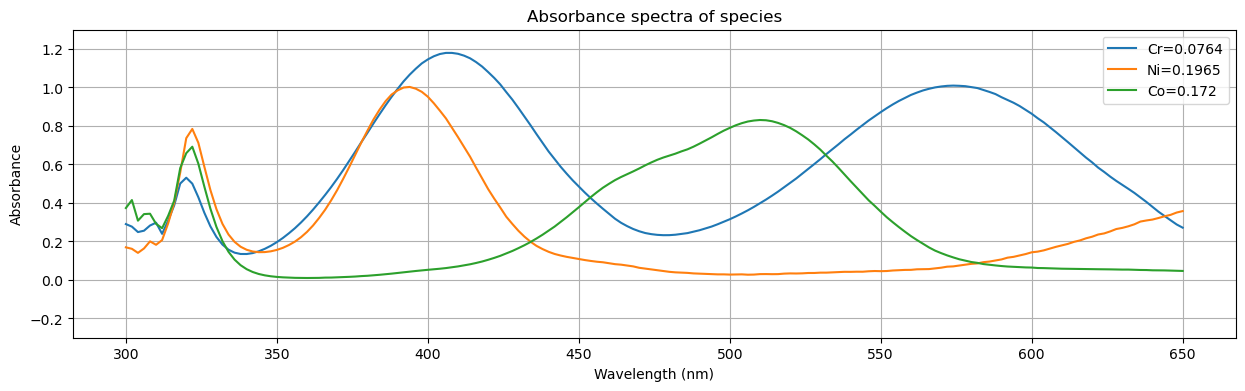

In [8]:
#Looping through each species to concatenate species name and its corresponding concentration in mol/litre
labels=[i+'='+str(j) for i,j in zip(species_con.columns,species_con.values.tolist()[0])]
plot_spectra(species_abs.T,labels,'Absorbance spectra of species',False)
show()

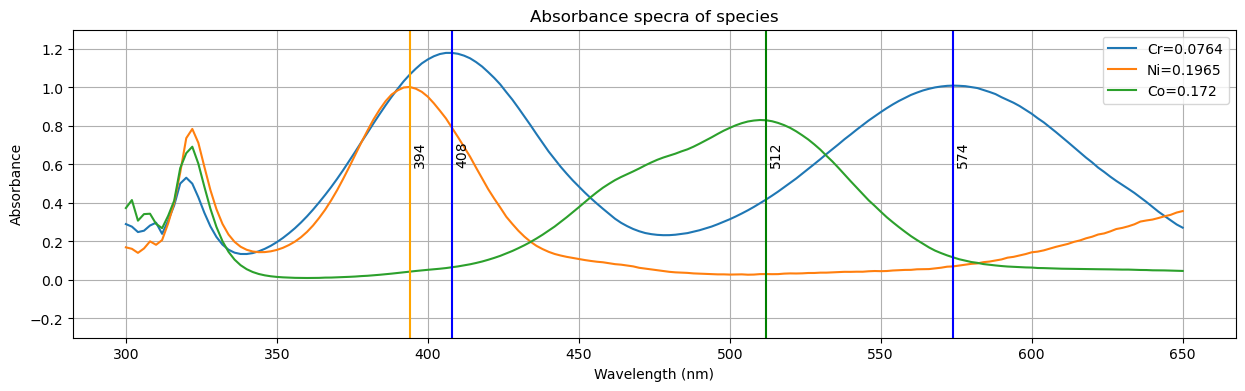

In [9]:
#Species spectra with vertical lines marking the absorption peaks
plot_spectra(species_abs.T,labels,'Absorbance specra of species',True)
show()

In [10]:
print(mixture_con.shape)
print(mixture_con.head(6))
print(mixture_abs.shape)
print(mixture_abs.head(6))

(130, 3)
         Cr        Ni        Co
0  0.003058  0.015715  0.006880
1  0.003058  0.015715  0.006880
2  0.003058  0.015715  0.006880
3  0.003058  0.015715  0.006880
4  0.003058  0.015715  0.006880
5  0.003058  0.015715  0.020639
(130, 176)
        300       302       304       306       308       310       312  \
0  0.130158  0.308899  0.103867  0.118942  0.057755 -0.047806  0.158752   
1  0.317703 -0.013901  0.316162  0.258423 -0.011780  0.294006 -0.090881   
2  0.010635  0.030945  0.062988  0.256409  0.142258  0.429672  0.028778   
3  0.075134 -0.155594  0.177795  0.062973  0.015518  0.046707  0.305450   
4  0.241013  0.326935 -0.051743  0.162659  0.123138  0.227310  0.109894   
5  0.203171 -0.072968  0.167343 -0.052307  0.035309 -0.066238 -0.007797   

        314       316       318  ...       632       634       636       638  \
0 -0.000565  0.162003  0.046326  ... -0.045319  0.074310  0.000000 -0.075104   
1 -0.079285  0.139648  0.066483  ... -0.099518  0.086761  0.196930  0.

In [11]:
'''
Function to get labels for the selected indices
Arguments: df (pandas.DataFrame), ind (list)
Returns: list of strings
'''
def get_labels(df,ind):
    mix_labels=[]
    for i in ind:
        label=''
        for j in range(3):
            label+=str(np.round(df.iloc[i,j],5))+'|'
        mix_labels.append(label)
    return mix_labels

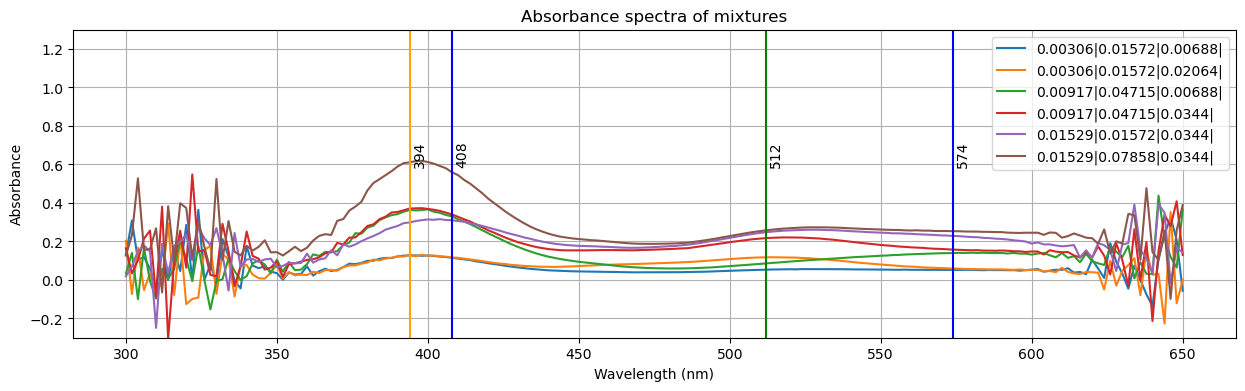

In [12]:
#Plot of absorbance spectra of selected mixtures from 130 samples
sel_ind=[0,5,60,70,100,129]
plot_spectra(mixture_abs.iloc[sel_ind,:].T,get_labels(mixture_con,sel_ind),'Absorbance spectra of mixtures',True)
show()

In [13]:
#Averaging every 5 repeated experiments for each mixture of species concentration
mix_avg_abs=((mixture_abs + mixture_abs.shift(-1)+mixture_abs.shift(-2)+mixture_abs.shift(-3)+mixture_abs.shift(-4)) / 5)[::5]
mix_uniq_con=mixture_con[::5]

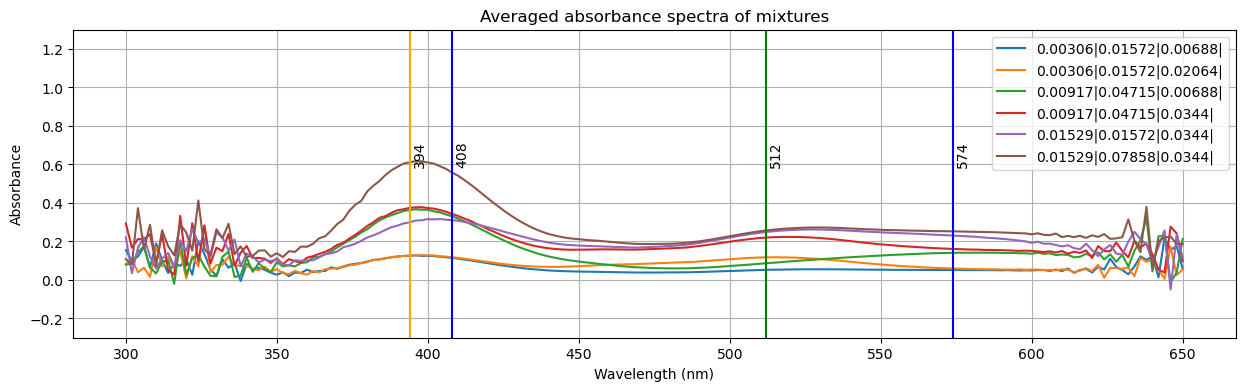

In [14]:
#Plot of the averaged spectra of mixtures for every 5 samples
avg_sel_ind = [0,1,12,14,20,25]
plot_spectra(mix_avg_abs.iloc[avg_sel_ind,:].T,get_labels(mix_uniq_con,avg_sel_ind),
'Averaged absorbance spectra of mixtures',True)
show()

In [15]:
# Importing model_selection library for using cross_validation
from sklearn import model_selection
# Importing the library for PCA
from sklearn.decomposition import PCA
# Importing the library for Linear Regression
from sklearn.linear_model import LinearRegression

In [16]:
'''
Function to linearly regress the training samples of X against Y
and to return the list of rmse for each variable in the output (y) of the testing samples
Arguments: X_train (numpy.ndarray),y_train (numpy.ndarray),X_test (numpy.ndarray),y_test (numpy.ndarray)
Returns: rmse (list of arrays)
'''
def linreg(X_train,X_test,y_train,y_test):
    ols = LinearRegression()    
    ols.fit(X_train, y_train)
    y_pred = ols.predict(X_test)
    rmse=np.sqrt(((y_test-y_pred)**2).mean(axis=0)) #square root (mean square error)
    return rmse

In [17]:
'''
Function to perform linear regression using leave one out cross validation between Y
and reduced set of X iteratively from 1 principal component to maximum number of principal coomponents specified
Arguments: X (numpy.ndarray), y (numpy.ndarray), nfact (int)
Returns: RMSE_pcr_arr (numpy.ndarray of size nfact,number of variables of y)
'''
def pca_loocv_ols(X,y,nfact):
    RMSE_pcr_lst=list()
    for pc in range(1,nfact,1): # Iterating over number of principal components
        pca = PCA(n_components=pc) # Instantiating pca instance for each number of principal components in the iteration process
        X_red = pca.fit_transform(X)
        rmse_pcr_lst=list()
        lcv = model_selection.LeaveOneOut() # Instantiating an lcv instance
        for tr_idx, tst_idx in lcv.split(X_red): # interating through multiple folds
            X_train, X_test = X_red[tr_idx], X_red[tst_idx] # input X for both train and test
            y_train, y_test = y[tr_idx], y[tst_idx] # output Y for both train and test
            rmse_pcr_lst.append(linreg(X_train,X_test,y_train,y_test)) # Appending rmse for each fold into a list
            #number of validations=26
        #number of PCR loops=25
        RMSE_pcr_lst.append(np.array(rmse_pcr_lst).mean(axis=0))
    return np.array(RMSE_pcr_lst)

In [18]:
#Using one of the five measurements (first) for each mixture for modelling and estimating maximum error in the model
mix_sample_abs=mixture_abs[::5] # Sampling every first sample from the 5 experiments of same mixture proportions of species
std_y=np.array(mix_uniq_con).std(axis=0) # estimating standard deviation in the Y corresponding to maximum error in the model
std_y=std_y.reshape(1,-1) # reshaping the vector(Ny,) to array (1,Ny) where Ny is number of variables in output array
std_y

array([[0.00493945, 0.0253862 , 0.01144835]])

In [19]:
#Performing pcr over sampled spectra of mixtures
RMSE_pcr_samples=np.append(std_y,pca_loocv_ols(np.array(mix_sample_abs),np.array(mix_uniq_con),26),axis=0)
RMSE_pcr_samples.shape

(26, 3)

In [20]:
#PCR over averaged X samples
RMSE_pcr_avg=np.append(std_y,pca_loocv_ols(np.array(mix_avg_abs),np.array(mix_uniq_con),26),axis=0)
RMSE_pcr_avg.shape

(26, 3)

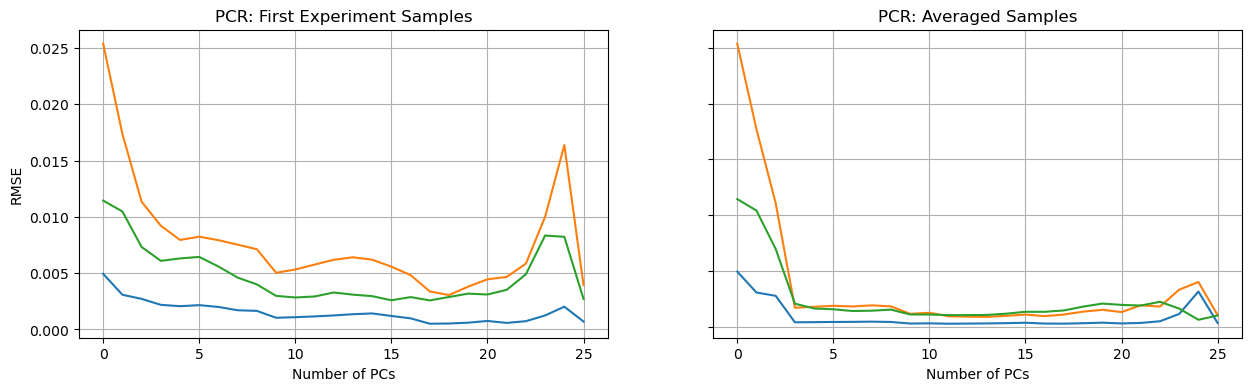

In [21]:
#Plot of RMSE against number of PCs for both sampled and averaged spectra
fig, axs = subplots(1, 2,figsize=(15,4))
axs[0].plot(range(26),RMSE_pcr_samples)
axs[0].set_title('PCR: First Experiment Samples')
axs[1].plot(range(26),RMSE_pcr_avg)
axs[1].set_title('PCR: Averaged Samples')
axs[0].grid(True)
axs[1].grid(True)
for ax in axs.flat:
    ax.set(xlabel='Number of PCs', ylabel='RMSE')
for ax in axs.flat:
    ax.label_outer()
show()